In [27]:
from typing import TypedDict,List
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv

In [28]:
!uv pip install langchain-ollama

Checked 1 package in 1.02s


In [29]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen2.5-coder:3b",
    temperature=0,
    
)

In [30]:
class AgentState(TypedDict):
    messages:List[HumanMessage]


In [31]:
def process(state:AgentState)->AgentState:
    ai_msg = llm.invoke(state["messages"])
    print(ai_msg.content)
    return state



In [32]:
graph=StateGraph(AgentState)
graph.add_node("process",process)

graph.add_edge(START,"process")
graph.add_edge("process",END)


agent=graph.compile()

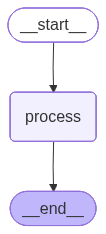

In [33]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png() ))

In [34]:
user_input=input("Enter : ")
agent.invoke({"messages":[HumanMessage(content=user_input)]})

Europe is a continent located in the northern part of the world, bordered by the Arctic Ocean to the north, the Atlantic Ocean to the west, and the Mediterranean Sea to the south. It also includes parts of Asia and Africa.

Some key points about Europe:

1. Size: Europe is the second-largest continent in the world, after Asia.

2. Countries: It consists of 47 countries, including 30 European Union (EU) member states.

3. Languages: The most widely spoken languages are English, French, German, Spanish, Italian, and Dutch.

4. Capital cities: Some major capital cities include Paris (France), Berlin (Germany), London (United Kingdom), Madrid (Spain), Rome (Italy), and Athens (Greece).

5. Geography: Europe is divided into several geographical regions, including the Northern European Plain, the Alps, the Mediterranean Sea coast, and the Black Sea region.

6. Economy: Europe has a highly developed economy with strong industries in manufacturing, services, and technology.

7. Culture: Europe

{'messages': [HumanMessage(content='europe', additional_kwargs={}, response_metadata={})]}